Test using sine/cosine encoding with latitude/longitude

In [74]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

In [4]:
# Longitude range -180 -> 180, latitude range -90 -> 90

In [96]:
def get_lon_lat_sin_cos_embed(embed_dim, lons, lats):
    omega = np.arange(embed_dim // 3 + 1, dtype=np.float32)
    omega /= embed_dim / 3.
    omega = 1. / (180/np.pi)**omega  # (D/2,)
    # reverse omega to put 1st lat/lon harmonic first:
    omega = omega[::-1]
    
    out_lon = np.einsum('m,d->md', lons.reshape(-1), omega)
    emb_sin_lon = np.sin(out_lon)
    emb_cos_lon = np.cos(out_lon)
    
    out_lat = np.einsum('m,d->md', lats.reshape(-1), omega)
    emb_sin_lat = np.sin(out_lat)
    
    emb = np.stack([emb_sin_lon, emb_cos_lon, emb_sin_lat], -1)
    emb = emb.reshape(lons.size, -1)[...,:embed_dim]

    return emb


In [97]:
emb = get_lon_lat_sin_cos_embed(256, *np.meshgrid(np.arange(-175,180,10), np.arange(-85,90,10), indexing="ij"))

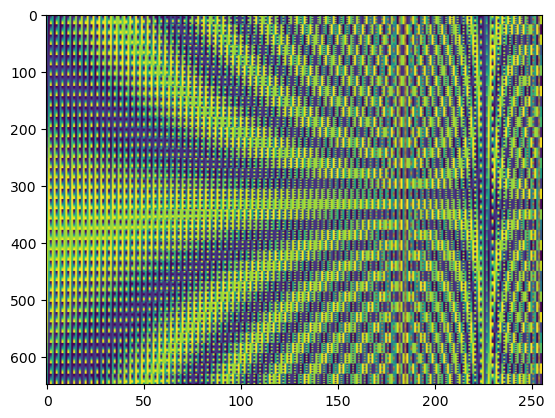

In [98]:
plt.imshow(emb,aspect="auto")

In [68]:
import pathlib
data_path = pathlib.Path("../data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))

In [77]:
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch import LightningDataModule
class GeoCloudsatDataset(Dataset):
    def __init__(self, files):
        super().__init__()
        self.files = files
    
    def __len__(self):
        return len(self.files)

    def load_image_and_geoloc(self, idx):
        with xr.open_datatree(self.files[idx]) as dt:
            image_input = dt.geo_patch.data.fillna(0)
            image_input[:6] = image_input[:6] / 100
            image_input[6:] = (image_input[6:] - 180) / 140 
            image_input = np.clip(image_input, 0, 1).values.astype(np.float32) * 2 -1 # normalise in range [-1,1]

            time_of_day = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
            time_of_year = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")

            # Fix latitude/longitude encoding:
            ds = dt.geo_patch
            if "latitude" in ds.data_vars and "longitude" in ds.data_vars:
                lat_offset = (
                    (ds.latitude.encoding["scale_factor"] + ds.latitude.encoding["add_offset"])*2
                    if ds.latitude.encoding["add_offset"] > 0
                    else 0
                )
                lon_offset = (
                    (ds.longitude.encoding["scale_factor"] + ds.longitude.encoding["add_offset"])*2
                    if ds.longitude.encoding["add_offset"] > 0
                    else 0
                )
                latitudes = (ds.latitude - lat_offset).fillna(ds.latitude.encoding["add_offset"])
                longitudes = (ds.longitude - lon_offset).fillna(ds.longitude.encoding["add_offset"])
            
            geoloc_input = np.stack([
                longitudes, 
                latitudes, 
                # dt.geo_patch.sat_angle[1], 
                # dt.geo_patch.sat_angle[0], 
                # dt.geo_patch.solar_angle[1], 
                # dt.geo_patch.solar_angle[0], 
                # np.full(dt.geo_patch.longitude.shape, time_of_day, np.float32), 
                # np.full(dt.geo_patch.longitude.shape, time_of_year, np.float32), 
            ], 0).astype(np.float32)

            cloudsat_offset = (dt.cloudsat_unaligned.Nray.size-256)//2
            cloudsat_unaligned = dt.cloudsat_unaligned.isel(Nray=slice(cloudsat_offset, cloudsat_offset+256))

            target = (cloudsat_unaligned.IWC.fillna(0).values.astype(np.float32) - np.float32(0.005482884130160449) ) / np.float32(0.07499345171049679)
            
            
            time_of_day = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
            time_of_year = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")
            
            geoloc_output = np.stack([
                cloudsat_unaligned.Longitude, 
                cloudsat_unaligned.Latitude, 
                # np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
                # np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
                # cloudsat_azi, # need to calc solar angles
                # cloudsat_sza, # need to calc solar angles
                # np.full(cloudsat_unaligned.Longitude.shape, time_of_day, np.float32), 
                # np.full(cloudsat_unaligned.Longitude.shape, time_of_year, np.float32), 
            ], 0).astype(np.float32)
            
        return image_input, geoloc_input, target, geoloc_output
    
    def __getitem__(self, idx):
        return self.load_image_and_geoloc(idx)

class GeoCloudsatDataloader(LightningDataModule):
    def __init__(
        self, 
        batch_size, 
        files, 
        num_workers=0, 
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Get list of files for each split
        self.train_dataset = GeoCloudsatDataset(files[:int(len(files)*0.7)])
        self.val_dataset = GeoCloudsatDataset(files[int(len(files)*0.75):int(len(files)*0.85)])
        self.test_dataset = GeoCloudsatDataset(files[int(len(files)*0.9):])

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=True, 
            num_workers=self.num_workers, 
        )

In [78]:
ds = GeoCloudsatDataset(files)

In [99]:
test_emb = get_lon_lat_sin_cos_embed(512, *ds[300][1][:,::16,::16])

In [100]:
test_emb.shape

(256, 512)

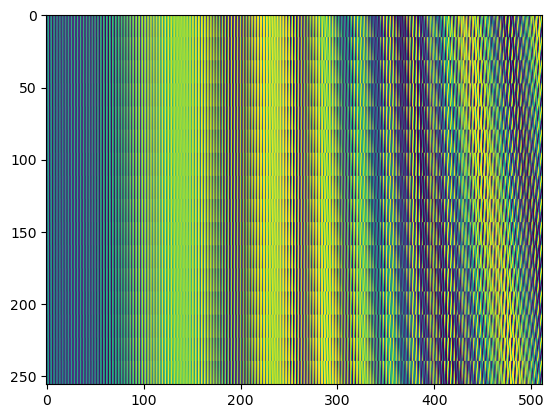

In [101]:
plt.imshow(test_emb,aspect="auto")

In [92]:
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    """
    grid_size: int of the grid height and width
    return:
    pos_embed: [grid_size*grid_size, embed_dim] or [1+grid_size*grid_size, embed_dim] (w/ or w/o cls_token)
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return pos_embed


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    """
    embed_dim: output dimension for each position
    pos: a list of positions to be encoded: size (M,)
    out: (M, D)
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

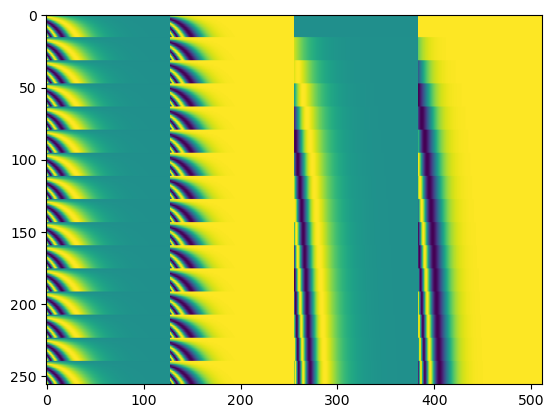

In [102]:
plt.imshow(get_2d_sincos_pos_embed(512, 16), aspect="auto")